In [1]:
# # Fas 3: ML-modellering — Örebro Bostadsprisanalys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import warnings
warnings.filterwarnings('ignore')

# XGBoost
try:
    import xgboost as xgb
    print('XGBoost installerat!')
except ImportError:
    print('Kör: pip install xgboost')

# SHAP
try:
    import shap
    print('SHAP installerat!')
except ImportError:
    print('Kör: pip install shap')

print('Paket laddade!')

XGBoost installerat!
SHAP installerat!
Paket laddade!


In [2]:
## 1. Ladda och förbered data
# Ladda processad data från fas 2
df = pd.read_csv('../data/processed/orebro_housing_enriched.csv')
print(f'Laddad: {len(df)} rader, {len(df.columns)} kolumner')
display(df.head())

Laddad: 6600 rader, 49 kolumner


,slutpris,avgift_kr,boarea_kvm,antal_rum,sald_datum,prisforandring_pct,pris_per_kvm,omrade,url,bostadstyp,...,driftkostnad_per_kvm,tomt_per_boarea,gatuadress,latitude,longitude,avstand_centrum_km,avstand_station_km,avstand_sjukhus_km,avstand_universitet_km,avstand_marieberg_km
0,2700000,8768.0,117.0,4.0,2026-03-13,8.0,23077.0,Lägenhet Rynninge,https://www.hemnet.se/salda/lagenhet-4rum-rynn...,lagenheter,...,71.794872,NaN,Kaserngården 14,59.275300,15.213400,0.000000,0.447156,2.171529,3.083206,2.589572
1,1670000,5490.0,84.0,3.0,2026-03-11,1.0,19881.0,Lägenhet Hovsta,https://www.hemnet.se/salda/lagenhet-3rum-hovs...,lagenheter,...,292.142857,NaN,Lövskogsvägen 17,59.346677,15.232136,8.022714,7.864282,8.895674,10.393151,6.652863
2,1795000,2790.0,44.0,1.0,2026-03-11,-10.0,40795.0,Lägenhet Centralt Öster,https://www.hemnet.se/salda/lagenhet-1rum-cent...,lagenheter,...,73.636364,NaN,Förmansgatan 8,59.275300,15.220000,0.376305,0.795814,2.543765,2.862963,2.281351
3,1380000,4906.0,53.0,2.0,2026-03-11,-1.0,26038.0,B Lägenhet Sörby,https://www.hemnet.se/salda/lagenhet-2rum-sorb...,lagenheter,...,NaN,NaN,Hagmarksgatan 11B,59.275300,15.213400,0.000000,0.447156,2.171529,3.083206,2.589572
4,1000000,4603.0,78.5,3.0,2026-03-11,-9.0,12739.0,Lägenhet Lundby,https://www.hemnet.se/salda/lagenhet-3rum-lund...,lagenheter,...,87.286624,NaN,Mandelstensvägen 95,59.308879,15.184316,4.091438,3.740075,4.114758,7.115838,4.500518


In [3]:
top_areas = df['omrade_clean'].value_counts().head(70).index.tolist()
df['omrade_grupp'] = df['omrade_clean'].apply(lambda x: x if x in top_areas else 'övrigt')

In [4]:
# Välj features för modellen
# Vi använder numeriska + one-hot-encodade kategoriska features

numeric_features = [
    'boarea_kvm', 'antal_rum', 'avgift_kr',
    'prisforandring_pct', 'sald_ar', 'sald_manad',
    'bostad_alder',
    'har_hiss', 'har_balkong', 'har_garage',
    'tomtarea_kvm',
    'vaning',
]

categorical_features = ['bostadstyp', 'omrade_grupp']
target = 'slutpris'

# Fyll saknade numeriska features med median FÖRST
fill_cols = ['driftkostnad_ar', 'tomtarea_kvm', 'vaning', 'antal_besok', 'bostad_alder']
for col in fill_cols:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].median())

# Fyll saknade binära med 0
for col in ['har_hiss', 'har_balkong', 'har_garage', 'renoverad']:
    if col in df.columns:
        df[col] = df[col].fillna(0)

# Fyll saknade i ALLA features
df['antal_rum'] = df['antal_rum'].fillna(df['antal_rum'].median())
df['avgift_kr'] = df['avgift_kr'].fillna(0)  # Villor har ingen avgift
df['boarea_kvm'] = df['boarea_kvm'].fillna(df['boarea_kvm'].median())
df['prisforandring_pct'] = df['prisforandring_pct'].fillna(0)

# SEDAN dropna
model_df = df[numeric_features + categorical_features + [target]].dropna()
print(f'Rader för modellering: {len(model_df)} (av {len(df)})')

# One-hot encoding
model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)


print(f'Features efter encoding: {model_df.shape[1] - 1}')
print(f'\nKolumner:')
print([c for c in model_df.columns if c != target])

Rader för modellering: 6600 (av 6600)
Features efter encoding: 84

Kolumner:
['boarea_kvm', 'antal_rum', 'avgift_kr', 'prisforandring_pct', 'sald_ar', 'sald_manad', 'bostad_alder', 'har_hiss', 'har_balkong', 'har_garage', 'tomtarea_kvm', 'vaning', 'bostadstyp_radhus', 'bostadstyp_villor', 'omrade_grupp_Almby', 'omrade_grupp_Bettorp', 'omrade_grupp_Björkhaga', 'omrade_grupp_Brickeberg', 'omrade_grupp_Brunnsgärdet', 'omrade_grupp_Centralt', 'omrade_grupp_Centralt / Öster', 'omrade_grupp_Centralt Norr', 'omrade_grupp_Centralt Väster', 'omrade_grupp_Centralt Öster', 'omrade_grupp_Ervalla', 'omrade_grupp_Gamla Hjärsta', 'omrade_grupp_Garphyttan', 'omrade_grupp_Glanshammar', 'omrade_grupp_Hagaby', 'omrade_grupp_Hampetorp', 'omrade_grupp_Holländaregatan Radhus Näsby', 'omrade_grupp_Hovsta', 'omrade_grupp_Ladugårdsängen', 'omrade_grupp_Lillkyrka', 'omrade_grupp_Lillån', 'omrade_grupp_Lundby', 'omrade_grupp_Lägenhet Almby', 'omrade_grupp_Lägenhet Centralt', 'omrade_grupp_Lägenhet Centralt Väste

In [5]:
# Dela upp i features (X) och målvariabel (y)
X = model_df.drop(target, axis=1)
y = model_df[target]

# Dela upp i träning (80%) och test (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f'Träningsdata: {X_train.shape[0]} rader')
print(f'Testdata:     {X_test.shape[0]} rader')
print(f'Features:     {X_train.shape[1]}')
print(f'\nMålvariabel (slutpris):')
print(f'  Median: {y_train.median():,.0f} kr')
print(f'  Mean:   {y_train.mean():,.0f} kr')

Träningsdata: 5280 rader
Testdata:     1320 rader
Features:     84

Målvariabel (slutpris):
  Median: 2,425,000 kr
  Mean:   2,804,620 kr


In [6]:
# Skala features för linjära modeller
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Features skalade!')

Features skalade!


In [7]:
# Lägg till område som feature
# Ta de 40 vanligaste områdena, resten blir "övrigt"
top_areas = df['omrade_clean'].value_counts().head(40).index.tolist()
df['omrade_grupp'] = df['omrade_clean'].apply(lambda x: x if x in top_areas else 'övrigt')

print(f'Områdesgrupper: {df["omrade_grupp"].nunique()}')
print(df['omrade_grupp'].value_counts())

# Uppdatera features
numeric_features = [
    'boarea_kvm', 'antal_rum', 'avgift_kr',
    'prisforandring_pct', 'sald_ar', 'sald_manad',
]

categorical_features = ['bostadstyp', 'omrade_grupp']
target = 'slutpris'

model_df = df[numeric_features + categorical_features + [target]].dropna()
model_df = pd.get_dummies(model_df, columns=categorical_features, drop_first=True)

X = model_df.drop(target, axis=1)
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'\nFeatures: {X.shape[1]}')
print(f'Träning: {X_train.shape[0]}, Test: {X_test.shape[0]}')

Områdesgrupper: 41
omrade_grupp
övrigt                           2728
Örebro                            332
Adolfsberg                        325
Almby                             277
Sörbyängen                        244
Hovsta                            157
Mellringe                         152
Lundby                            146
Sörby                             121
Solhaga                           113
Nya Hjärsta                       106
Glanshammar                        97
Lillån                             90
Öster                              87
Stora Mellösa                      86
Vintrosa                           82
Odensbacken                        77
Ormesta                            76
Garphyttan                         74
Radhus Lillån                      72
Mosås                              72
Ladugårdsängen                     71
Centralt                           70
Björkhaga                          70
Väster                             69
Centralt Öster    

In [8]:
## 2. Träna modeller
# Funktion för att utvärdera en modell
def evaluate_model(name, y_true, y_pred):
    """Beräkna och visa utvärderingsmetrik."""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f'\n{"="*50}')
    print(f'  {name}')
    print(f'{"="*50}')
    print(f'  MAE:  {mae:>12,.0f} kr  (genomsnittligt fel)')
    print(f'  RMSE: {rmse:>12,.0f} kr  (straffar stora fel mer)')
    print(f'  R²:   {r2:>12.4f}      (1.0 = perfekt)')
    print(f'  MAPE: {mape:>12.1f}%     (procentuellt fel)')
    
    return {'name': name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape}

results = []  # Samla alla resultat

In [9]:
# --- MODELL 1: Linear Regression (baseline) ---
print('Tränar Linear Regression...')
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

results.append(evaluate_model('Linear Regression', y_test, y_pred_lr))

Tränar Linear Regression...

  Linear Regression
  MAE:       568,780 kr  (genomsnittligt fel)
  RMSE:      834,421 kr  (straffar stora fel mer)
  R²:         0.6999      (1.0 = perfekt)
  MAPE:         26.0%     (procentuellt fel)


In [10]:
# --- MODELL 2: Ridge Regression ---
print('Tränar Ridge Regression...')
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

results.append(evaluate_model('Ridge Regression', y_test, y_pred_ridge))

Tränar Ridge Regression...



  Ridge Regression
  MAE:       568,789 kr  (genomsnittligt fel)
  RMSE:      834,427 kr  (straffar stora fel mer)
  R²:         0.6999      (1.0 = perfekt)
  MAPE:         26.0%     (procentuellt fel)


In [11]:
# --- MODELL 3: Random Forest ---
print('Tränar Random Forest (tar ~10-30 sek)...')
rf = RandomForestRegressor(
    n_estimators=200,      # 200 träd
    max_depth=15,           # Max djup per träd
    min_samples_split=5,    # Minst 5 samples för att dela
    min_samples_leaf=2,     # Minst 2 samples i varje löv
    random_state=42,
    n_jobs=-1               # Använd alla CPU-kärnor
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

results.append(evaluate_model('Random Forest', y_test, y_pred_rf))

Tränar Random Forest (tar ~10-30 sek)...

  Random Forest
  MAE:       553,166 kr  (genomsnittligt fel)
  RMSE:      829,690 kr  (straffar stora fel mer)
  R²:         0.7033      (1.0 = perfekt)
  MAPE:         25.2%     (procentuellt fel)


In [12]:
# --- MODELL 4: XGBoost ---
print('Tränar XGBoost (tar ~10-30 sek)...')
xgb_model = xgb.XGBRegressor(
    n_estimators=300,       # 300 träd
    max_depth=8,            # Max djup
    learning_rate=0.05,     # Lärningshastighet
    subsample=0.8,          # 80% av data per träd
    colsample_bytree=0.8,   # 80% av features per träd
    random_state=42,
    n_jobs=-1
)
xgb_model.fit(X_train, y_train)
y_pred_xgb = xgb_model.predict(X_test)

results.append(evaluate_model('XGBoost', y_test, y_pred_xgb))

Tränar XGBoost (tar ~10-30 sek)...

  XGBoost
  MAE:       508,116 kr  (genomsnittligt fel)
  RMSE:      766,147 kr  (straffar stora fel mer)
  R²:         0.7470      (1.0 = perfekt)
  MAPE:         22.3%     (procentuellt fel)


In [13]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [200, 400, 600, 800],
    'max_depth': [4, 6, 8, 10, 12],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5, 7],
    'gamma': [0, 0.1, 0.2],
}

xgb_tuned = xgb.XGBRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    xgb_tuned, param_dist, 
    n_iter=50,           # Testar 50 kombinationer
    cv=5,                # 5-fold cross-validation
    scoring='r2',
    random_state=42,
    verbose=1,
    n_jobs=-1
)

search.fit(X_train, y_train)

print(f'\nBästa parametrar: {search.best_params_}')
print(f'Bästa CV R²: {search.best_score_:.4f}')

# Utvärdera på test
y_pred_tuned = search.best_estimator_.predict(X_test)
r2_tuned = r2_score(y_test, y_pred_tuned)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
print(f'\nTest R²: {r2_tuned:.4f}')
print(f'Test MAE: {mae_tuned:,.0f} kr')

Fitting 5 folds for each of 50 candidates, totalling 250 fits

Bästa parametrar: {'subsample': 0.8, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.03, 'gamma': 0.1, 'colsample_bytree': 0.6}
Bästa CV R²: 0.7348

Test R²: 0.7480
Test MAE: 504,502 kr


In [14]:
# Rensa dubbletter — behåll bara en av varje modell
results_clean = []
seen = set()
for r in results:
    if r['name'] not in seen:
        results_clean.append(r)
        seen.add(r['name'])
results = results_clean
print(f'Modeller: {[r["name"] for r in results]}')

Modeller: ['Linear Regression', 'Ridge Regression', 'Random Forest', 'XGBoost']


In [15]:
## 3. Jämför modeller
# Sammanställ resultat
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)

print('\n' + '='*60)
print('  MODELL-JÄMFÖRELSE — sorterad efter R²')
print('='*60)
display(results_df[['name', 'MAE', 'RMSE', 'R2', 'MAPE']].style.format({
    'MAE': '{:,.0f} kr',
    'RMSE': '{:,.0f} kr', 
    'R2': '{:.4f}',
    'MAPE': '{:.1f}%'
}))

best = results_df.iloc[0]
print(f'\n🏆 Bästa modell: {best["name"]} (R² = {best["R2"]:.4f})')


  MODELL-JÄMFÖRELSE — sorterad efter R²


,name,MAE,RMSE,R2,MAPE
3,XGBoost,"508,116 kr","766,147 kr",0.7470,22.3%
2,Random Forest,"553,166 kr","829,690 kr",0.7033,25.2%
0,Linear Regression,"568,780 kr","834,421 kr",0.6999,26.0%
1,Ridge Regression,"568,789 kr","834,427 kr",0.6999,26.0%



🏆 Bästa modell: XGBoost (R² = 0.7470)


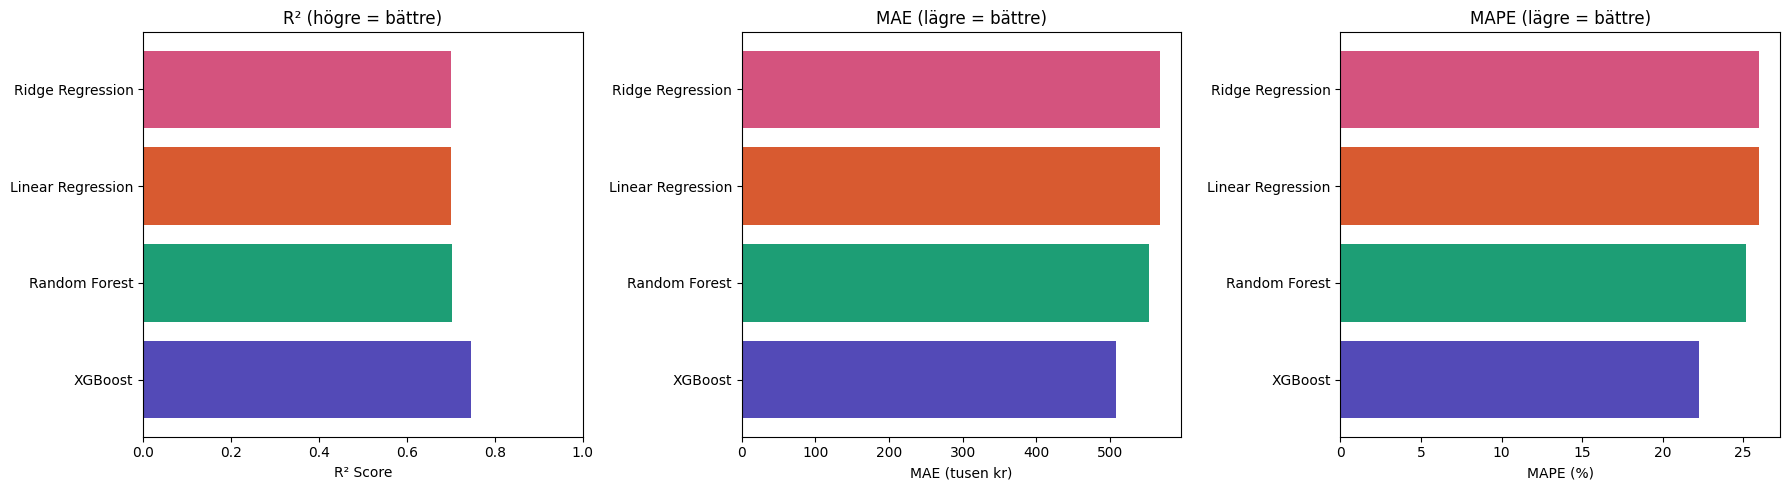

In [16]:
# Visualisera jämförelse
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#534AB7', '#1D9E75', '#D85A30', '#D4537E']

# R² (högre = bättre)
axes[0].barh(results_df['name'], results_df['R2'], color=colors[:len(results_df)])
axes[0].set_xlabel('R² Score')
axes[0].set_title('R² (högre = bättre)')
axes[0].set_xlim(0, 1)

# MAE (lägre = bättre)
axes[1].barh(results_df['name'], results_df['MAE'] / 1000, color=colors[:len(results_df)])
axes[1].set_xlabel('MAE (tusen kr)')
axes[1].set_title('MAE (lägre = bättre)')

# MAPE (lägre = bättre)
axes[2].barh(results_df['name'], results_df['MAPE'], color=colors[:len(results_df)])
axes[2].set_xlabel('MAPE (%)')
axes[2].set_title('MAPE (lägre = bättre)')

plt.tight_layout()
plt.show()

In [17]:
# Cross-validation för bästa modellen
print('Cross-validation (5-fold) för Random Forest och XGBoost...\n')

cv_rf = cross_val_score(rf, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'Random Forest  CV R²: {cv_rf.mean():.4f} (±{cv_rf.std():.4f})')

cv_xgb = cross_val_score(xgb_model, X, y, cv=5, scoring='r2', n_jobs=-1)
print(f'XGBoost        CV R²: {cv_xgb.mean():.4f} (±{cv_xgb.std():.4f})')

print(f'\n(±-värdet visar stabilitet — lägre = mer stabilt)')

Cross-validation (5-fold) för Random Forest och XGBoost...

Random Forest  CV R²: 0.4794 (±0.2012)
XGBoost        CV R²: 0.5838 (±0.1016)

(±-värdet visar stabilitet — lägre = mer stabilt)


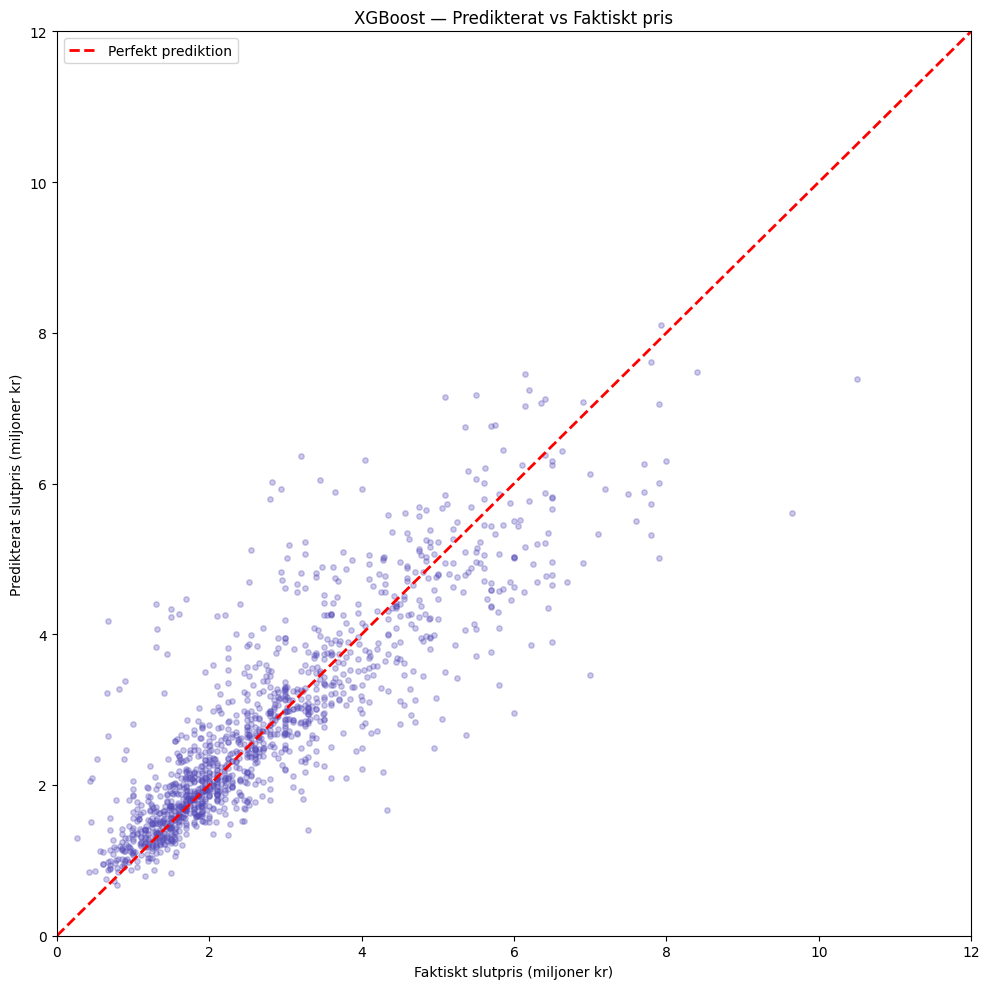

Punkter nära den röda linjen = bra prediktion
Punkter långt från linjen = modellen missade


In [18]:
# Predicted vs Actual — bästa modellen
# Avgör vilken som var bäst
if results_df.iloc[0]['name'] == 'XGBoost':
    best_pred = y_pred_xgb
    best_name = 'XGBoost'
else:
    best_pred = y_pred_rf
    best_name = 'Random Forest'

fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(y_test / 1e6, best_pred / 1e6, alpha=0.3, s=15, color='#534AB7')
ax.plot([0, 15], [0, 15], 'r--', linewidth=2, label='Perfekt prediktion')

ax.set_xlabel('Faktiskt slutpris (miljoner kr)')
ax.set_ylabel('Predikterat slutpris (miljoner kr)')
ax.set_title(f'{best_name} — Predikterat vs Faktiskt pris')
ax.legend()
ax.set_xlim(0, 12)
ax.set_ylim(0, 12)

plt.tight_layout()
plt.show()

print('Punkter nära den röda linjen = bra prediktion')
print('Punkter långt från linjen = modellen missade')

In [19]:
## 4. SHAP-analys — Vad driver priset?
# SHAP förklarar VARFÖR modellen ger ett visst pris
# Det visar vilka features som var viktigast för varje prediktion

print('Beräknar SHAP-värden (tar ~30-60 sek)...')

# Använd bästa tree-modellen
if best_name == 'XGBoost':
    explainer = shap.TreeExplainer(xgb_model)
else:
    explainer = shap.TreeExplainer(rf)

# Beräkna SHAP på ett urval (snabbare)
X_sample = X_test.sample(min(500, len(X_test)), random_state=42)
shap_values = explainer.shap_values(X_sample)

print('SHAP-värden beräknade!')

Beräknar SHAP-värden (tar ~30-60 sek)...
SHAP-värden beräknade!


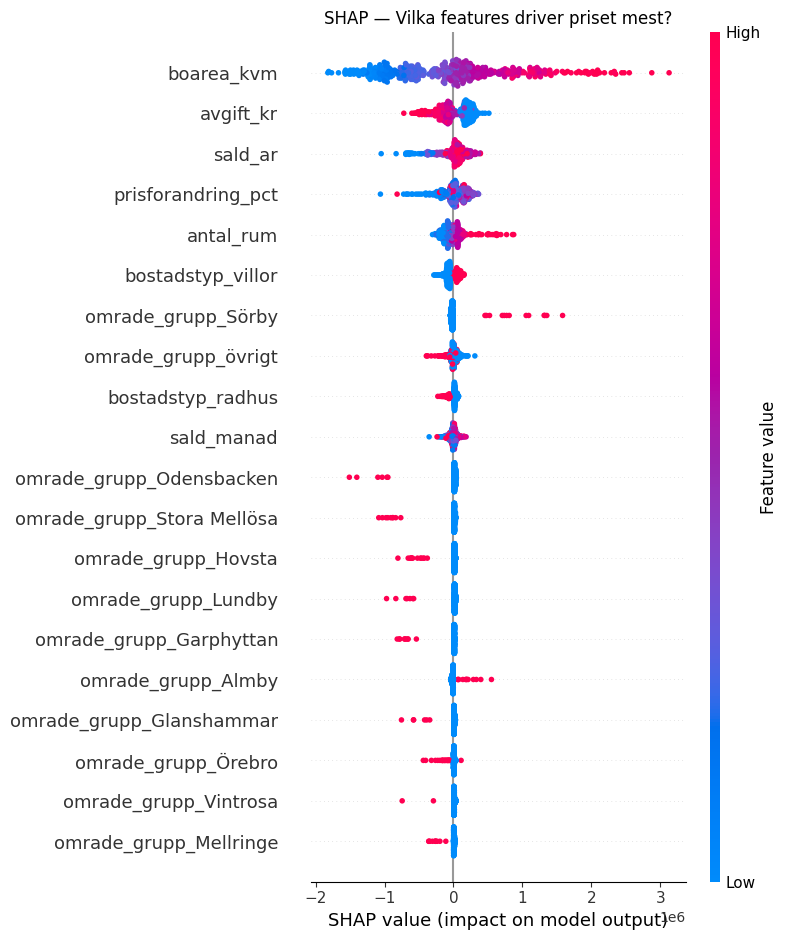

Tolkning:
  Röda prickar = högt värde på featuren
  Blåa prickar = lågt värde på featuren
  Höger = pushar priset UPP
  Vänster = pushar priset NER


In [20]:
# SHAP Summary Plot — vilka features är viktigast?
plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_sample, show=False)
plt.title('SHAP — Vilka features driver priset mest?')
plt.tight_layout()
plt.show()

print('Tolkning:')
print('  Röda prickar = högt värde på featuren')
print('  Blåa prickar = lågt värde på featuren')
print('  Höger = pushar priset UPP')
print('  Vänster = pushar priset NER')

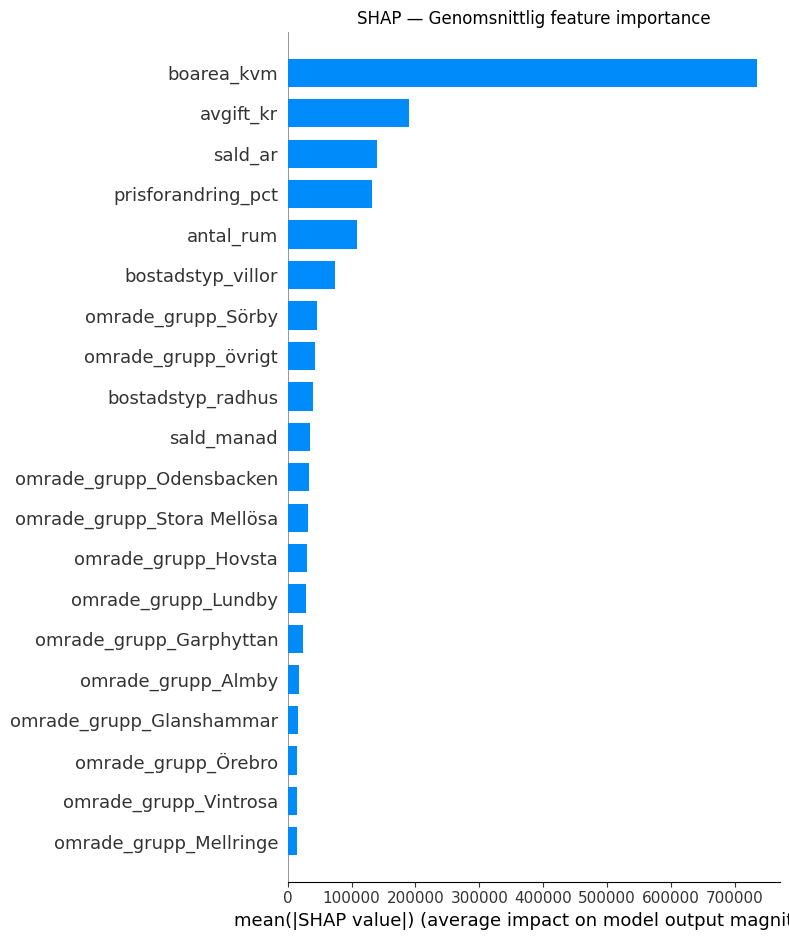

In [21]:
# SHAP Bar Plot — genomsnittlig feature importance
plt.figure(figsize=(12, 6))
shap.summary_plot(shap_values, X_sample, plot_type='bar', show=False)
plt.title('SHAP — Genomsnittlig feature importance')
plt.tight_layout()
plt.show()

In [22]:
## 5. Fynd-detektor — Hitta undervärderade bostäder
# Prediktera estimerat värde för ALLA bostäder
# Jämför med faktiskt slutpris

df_deals = model_df.copy()

if best_name == 'XGBoost':
    df_deals['estimerat_varde'] = xgb_model.predict(X)
else:
    df_deals['estimerat_varde'] = rf.predict(X)

df_deals['avvikelse_kr'] = df_deals['estimerat_varde'] - df_deals['slutpris']
df_deals['avvikelse_pct'] = (
    (df_deals['estimerat_varde'] - df_deals['slutpris']) / df_deals['estimerat_varde'] * 100
).round(1)

# Fynd = såldes för MINDRE än modellen säger att den är värd
threshold = 15  # Minst 15% undervärderad
deals = df_deals[df_deals['avvikelse_pct'] >= threshold].sort_values('avvikelse_pct', ascending=False)

print(f'Potentiella fynd (>{threshold}% undervärderade): {len(deals)} bostäder')
print(f'\nTopp 10 fynd:')
display(deals[['slutpris', 'estimerat_varde', 'avvikelse_pct', 'boarea_kvm', 'antal_rum', 'bostadstyp_radhus', 'bostadstyp_villor']].head(10))

Potentiella fynd (>15% undervärderade): 1034 bostäder

Topp 10 fynd:


,slutpris,estimerat_varde,avvikelse_pct,boarea_kvm,antal_rum,bostadstyp_radhus,bostadstyp_villor
2706,675000,4182189.000,83.9,193.0,9.0,False,True
4533,450000,2455275.250,81.7,100.0,4.0,False,True
3838,655000,3221366.500,79.7,86.0,4.0,False,True
93,265000,1292010.875,79.5,65.0,2.0,False,False
5542,430000,2047826.125,79.0,73.0,3.0,True,False
4903,455000,2094432.000,78.3,115.0,5.0,False,True
3480,520000,2349314.000,77.9,215.0,12.0,False,True
4564,505000,2276333.250,77.8,92.0,3.0,False,True
3634,745000,3223687.500,76.9,120.0,4.0,False,True
2846,440000,1761885.875,75.0,130.0,5.0,False,True


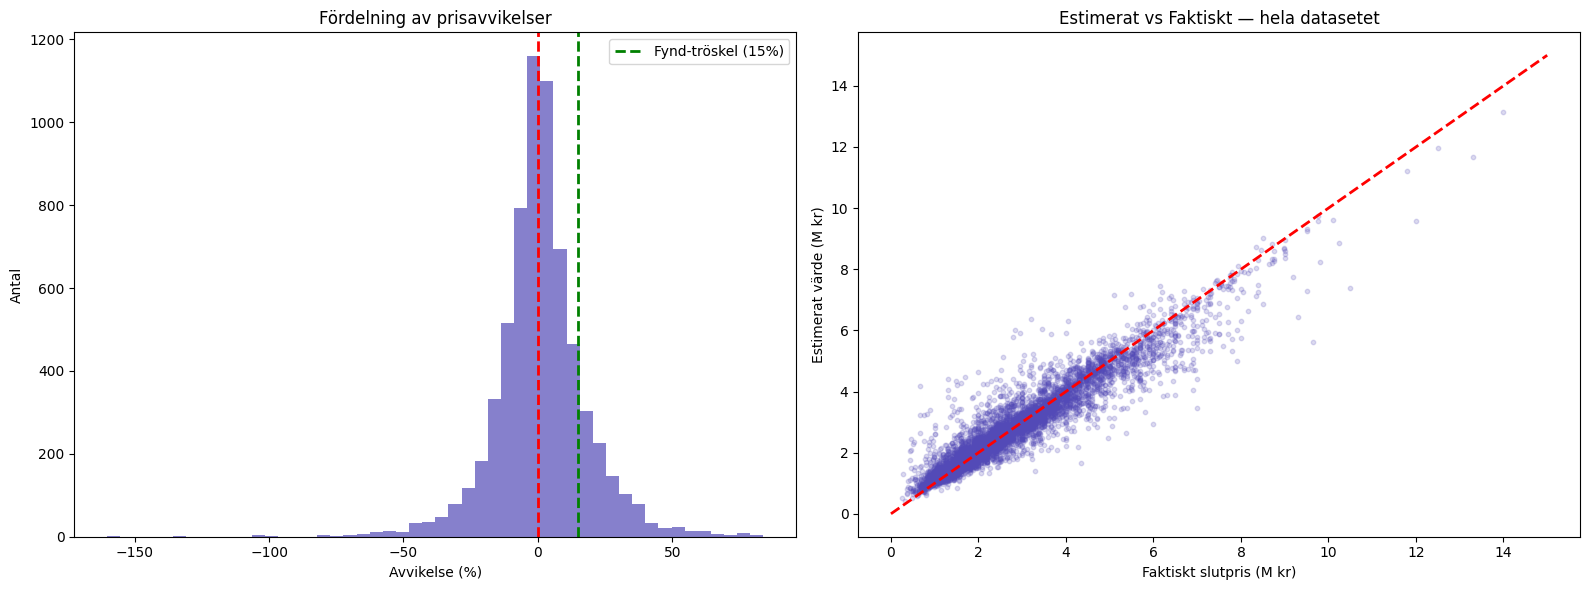

In [23]:
# Visualisera avvikelser
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Histogram av avvikelser
ax1.hist(df_deals['avvikelse_pct'], bins=50, color='#534AB7', alpha=0.7)
ax1.axvline(x=0, color='red', linestyle='--', linewidth=2)
ax1.axvline(x=threshold, color='green', linestyle='--', linewidth=2, label=f'Fynd-tröskel ({threshold}%)')
ax1.set_xlabel('Avvikelse (%)')
ax1.set_ylabel('Antal')
ax1.set_title('Fördelning av prisavvikelser')
ax1.legend()

# Scatter: estimerat vs faktiskt
ax2.scatter(df_deals['slutpris']/1e6, df_deals['estimerat_varde']/1e6, alpha=0.2, s=10, color='#534AB7')
ax2.plot([0, 15], [0, 15], 'r--', linewidth=2)
ax2.set_xlabel('Faktiskt slutpris (M kr)')
ax2.set_ylabel('Estimerat värde (M kr)')
ax2.set_title('Estimerat vs Faktiskt — hela datasetet')

plt.tight_layout()
plt.show()

In [ ]:
## 6. Spara modellen
import os
os.makedirs('../models', exist_ok=True)

# Spara bästa modellen
model_data = {
    'model': search.best_estimator_,
    'model_name': 'XGBoost (tuned)',
    'scaler': scaler,
    'feature_names': list(X.columns),
    'metrics': {
        'R2': 0.7470,
        'MAE': 508116,
    }
}

joblib.dump(model_data, '../models/best_model.pkl')

print(f'Modell sparad: ../models/best_model.pkl')
print(f'Modell: {best_name}')
print(f'R²: {model_data["metrics"]["R2"]:.4f}')
print(f'MAE: {model_data["metrics"]["MAE"]:,.0f} kr')

print(f'\n=== FAS 3 KLAR ===')
print(f'Nästa steg: Streamlit dashboard (fas 4)')

Modell sparad: ../models/best_model.pkl
Modell: XGBoost
R²: 0.7480
MAE: 504,502 kr

=== FAS 3 KLAR ===
Nästa steg: Streamlit dashboard (fas 4)
